# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c21_surrogate_model_training  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-03-19
### Properties script
**Goal:** To train a surrogate model on a CSV dataset resulting from structural analyses done in grasshopper, this surrogate model should be able to accurately tell if a beam in the structure is structurally failing or not   
**Inputs:**
*   CSV with structural properties, from grasshopper

**Outputs:**
*   A surrogate model????

# PARAMETERS

In [1]:
import config

USE_NEWEST = True  # Zet op True om data_4.csv te gebruiken
CSV_FILE = 'data_3.1.csv' if USE_NEWEST else 'data_3.0.csv'
print(f"Actieve dataset: {CSV_FILE}")

# ============================================
# WORKFLOW TOGGLE: Train from scratch OR use pre-trained model
# ============================================
USE_PRETRAINED = False  # Set to True to load a pre-trained model instead of training
PRETRAINED_MODEL_PREFIX = "data_4_0000"  # Change this to match your pre-trained model filename

# Training runtime options (only used if USE_PRETRAINED=False)
USE_TRAINING_TIME_LIMIT = False  # Zet op True voor korte test-runs
TRAINING_TIME_LIMIT_SECONDS = 60

# BENAMING VAN BESTAND EN NETWERK ARCHITECTUUR
schone_naam = CSV_FILE.replace('.csv', '')
delen = schone_naam.split('_')

OPTIMIZATION_TYPE = delen[0] if len(delen) > 0 else 'UNKNOWN'
DATE = delen[1] if len(delen) > 1 else '000000'
ITERATION = delen[2] if len(delen) > 2 else '0000'

prefix_sm = f"{OPTIMIZATION_TYPE}_{DATE}_{ITERATION}"
with open(config.SM_EXPORT_PATH / 'prefix_sm.txt', 'w') as f:
    f.write(prefix_sm)

✅ Systeem succesvol geladen.
📂 Code draait lokaal vanuit: thesis_generative_timber
☁️ Data gekoppeld aan OneDrive: 2.2 - 2.4
Actieve dataset: data_3.1.csv


# IMPORTING DATA

In [2]:
import config
import pandas as pd
import torch
import json
import re

print("1. Dataset inladen...")
df = pd.read_csv(config.GH_DATA_PATH / CSV_FILE)
print(f"✅ Dataset '{CSV_FILE}' ingeladen.")

with open(config.DATA_IO_PATH / 'edge_index.json', 'r') as f:
    edge_index = torch.tensor(json.load(f), dtype=torch.long)

# 2. Harde validatie van de dimensies
print("\n--- DATA VALIDATIE ---")
print(f"Aantal samples (rijen) in dataset: {len(df)}")
print(f"Totaal aantal kolommen in dataset: {df.shape[1]}")
print(f"Dimensie van de edge_index tensor: {edge_index.shape}")

# Dynamisch node- en edge-aantal afleiden uit de data
NODE_IDS = sorted({int(m.group(1)) for col in df.columns if (m := re.match(r'^v(\d+)_x$', col))})
assert NODE_IDS, "Fout: geen node-coordinaten gevonden in CSV (verwacht kolommen zoals v0_x)."
NODE_COUNT = len(NODE_IDS)

EDGE_COLS = sorted(
    [col for col in df.columns if re.match(r'^beam\d+_a_force$', col)],
    key=lambda c: int(re.match(r'^beam(\d+)_a_force$', c).group(1))
)
EDGE_COUNT = len(EDGE_COLS)

# Korte sanity check: detecteer automatisch of support/load features aanwezig zijn
for i in NODE_IDS:
    assert f"v{i}_y" in df.columns and f"v{i}_z" in df.columns, f"Fout: missende y/z kolommen voor vertex v{i}."

has_support_cols = all(f"v{i}_is_support" in df.columns for i in NODE_IDS)
has_load_cols = all(f"v{i}_load_z" in df.columns for i in NODE_IDS)
assert has_support_cols == has_load_cols, "Fout: onvolledige node-features. Verwacht per vertex zowel is_support als load_z."
NODE_FEATURE_DIM = 5 if (has_support_cols and has_load_cols) else 3
expected_columns = 1 + (NODE_COUNT * NODE_FEATURE_DIM) + EDGE_COUNT  # +1 voor sample_id
assert df.shape[1] == expected_columns, f"Fout: CSV heeft {df.shape[1]} kolommen, verwacht {expected_columns} op basis van schema."
assert edge_index.shape[0] == 2, "Fout: edge_index moet precies 2 rijen hebben (source en target nodes)."
assert edge_index.shape[1] == EDGE_COUNT, f"Fout: edge_index moet precies {EDGE_COUNT} kolommen (verbindingen) hebben."

print(f"Node count gedetecteerd: {NODE_COUNT}")
print(f"Edge count gedetecteerd: {EDGE_COUNT}")
print(f"Node feature dim gedetecteerd: {NODE_FEATURE_DIM}")
print("Validatie succesvol. Data is correct ingeladen.")

1. Dataset inladen...
✅ Dataset 'data_3.1.csv' ingeladen.

--- DATA VALIDATIE ---
Aantal samples (rijen) in dataset: 10000
Totaal aantal kolommen in dataset: 98
Dimensie van de edge_index tensor: torch.Size([2, 32])
Node count gedetecteerd: 13
Edge count gedetecteerd: 32
Node feature dim gedetecteerd: 5
Validatie succesvol. Data is correct ingeladen.


# PROCESSING DATA

In [3]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import os

# 1. Normalisatie (Scaling) instellen
# Neurale netwerken werken wiskundig het best met getallen rond de 0.
print("Start data normalisatie...")
node_scaler = StandardScaler()
edge_scaler = StandardScaler()

# Kolomnamen vooraf opbouwen
if NODE_FEATURE_DIM == 5:
    # Voor data_4: x, y, z, load_z en is_support per vertex
    node_cols = [f"v{i}_{feat}" for i in NODE_IDS for feat in ("x", "y", "z", "load_z", "is_support")]
else:
    node_cols = [f"v{i}_{axis}" for i in NODE_IDS for axis in ("x", "y", "z")]
edge_cols = EDGE_COLS

# 2. Ruwe data in 1x vectorized stap ophalen en herschalen
node_raw = df[node_cols].to_numpy(dtype=np.float32).reshape(-1, NODE_COUNT, NODE_FEATURE_DIM)
edge_raw = df[edge_cols].to_numpy(dtype=np.float32).reshape(-1, EDGE_COUNT, 1)

if NODE_FEATURE_DIM == 5:
    # Schaal alleen continue features; houd binaire support feature op 0/1
    node_continuous = node_raw[:, :, :4]
    node_support = node_raw[:, :, 4:5]
    node_scaler.fit(node_continuous.reshape(-1, 4))
    node_continuous_scaled = node_scaler.transform(node_continuous.reshape(-1, 4)).reshape(-1, NODE_COUNT, 4)
    node_scaled = np.concatenate([node_continuous_scaled, node_support], axis=2)
else:
    node_scaler.fit(node_raw.reshape(-1, 3))
    node_scaled = node_scaler.transform(node_raw.reshape(-1, 3)).reshape(-1, NODE_COUNT, 3)
edge_scaler.fit(edge_raw.reshape(-1, 1))

edge_scaled = edge_scaler.transform(edge_raw.reshape(-1, 1)).reshape(-1, EDGE_COUNT, 1)

# 3. Dataset opbouwen met de genormaliseerde data
print("Bouwen van Graph objecten...")
graph_dataset = [
    Data(
        x=torch.from_numpy(node_scaled[i]),
        edge_index=edge_index,
        y_edge=torch.from_numpy(edge_scaled[i])
    )
    for i in range(len(df))
]

# 4. Splitsen in Train (80%) en Test (20%) met vaste seed voor reproduceerbaarheid
rng = np.random.default_rng(42)
indices = rng.permutation(len(graph_dataset))
train_size = int(0.8 * len(graph_dataset))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

train_dataset = [graph_dataset[i] for i in train_idx]
test_dataset = [graph_dataset[i] for i in test_idx]

# 5. DataLoaders tunen voor efficiëntere input pipeline
loader_kwargs = {
    "batch_size": 32,
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": torch.cuda.is_available()
}
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f"Dataset klaar! Train set: {len(train_dataset)} graphs. Test set: {len(test_dataset)} graphs.")

c:\Users\jaspe\Documents\PyEnvs\thesis_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Start data normalisatie...
Bouwen van Graph objecten...
Dataset klaar! Train set: 8000 graphs. Test set: 2000 graphs.


# MODEL SETUP

In [4]:
from c21_surrogate_model import TrussEdgeGNN
import torch
import joblib

# Reset het model op je device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if USE_PRETRAINED:
    # Load pre-trained model
    print(f"\n🔄 LOADING PRE-TRAINED MODEL: {PRETRAINED_MODEL_PREFIX}")
    checkpoint = torch.load(config.SM_EXPORT_PATH / f"truss_edge_gnn_{PRETRAINED_MODEL_PREFIX}.pt")
    model = TrussEdgeGNN(node_in_dim=checkpoint['node_in_dim'], hidden_dim=checkpoint['hidden_dim']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load pre-trained scalers
    node_scaler = joblib.load(config.SM_EXPORT_PATH / f"node_scaler_{PRETRAINED_MODEL_PREFIX}.pkl")
    edge_scaler = joblib.load(config.SM_EXPORT_PATH / f"edge_scaler_{PRETRAINED_MODEL_PREFIX}.pkl")
    
    # Use model prefix for evaluation output
    model_prefix = PRETRAINED_MODEL_PREFIX
    
    print(f"✅ Pre-trained model and scalers loaded successfully.\n")
else:
    # Initialize fresh model for training
    print(f"\n🆕 INITIALIZING FRESH MODEL FOR TRAINING")
    model = TrussEdgeGNN(node_in_dim=NODE_FEATURE_DIM, hidden_dim=128).to(device)
    model_prefix = prefix_sm
    print(f"✅ Fresh model initialized.\n")

print(f"Model device: {device}")
print("\n--- MODEL ARCHITECTUUR ---")
print(model)


🆕 INITIALIZING FRESH MODEL FOR TRAINING
✅ Fresh model initialized.

Model device: cpu

--- MODEL ARCHITECTUUR ---
TrussEdgeGNN(
  (conv1): SAGEConv(5, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (conv3): SAGEConv(128, 128, aggr=mean)
  (conv4): SAGEConv(128, 128, aggr=mean)
  (edge_predictor): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


# MODEL TRAINING

In [5]:
from sklearn.metrics import r2_score
import time

# Initialize history containers so plotting works in both modes
epoch_history = []
train_loss_history = []

# Skip training if using pre-trained model
if USE_PRETRAINED:
    print("\n⏭️  SKIPPING TRAINING (using pre-trained model)")
else:
    print("\n🚀 STARTING TRAINING...\n")
    
    # ==========================================
    # 1. SETUP VAN DE OPTIMIZER EN LOSS FUNCTIE
    # ==========================================
    # lr=0.001 is je startwaarde. Pas deze aan als de Loss explodeert of stagneert.
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    # optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

    # Mean Squared Error (MSE) is de standaard voor regressie (het voorspellen van continue getallen)
    criterion = torch.nn.MSELoss()

    EPOCHS = 50
    # EPOCHS = 1000  # Voor langere training (pas aan op basis van je tijdslimiet)
    EVAL_EVERY = 10
    train_start_time = time.time()

    if USE_TRAINING_TIME_LIMIT:
        print(f"Start training voor {EPOCHS} epochs (max {TRAINING_TIME_LIMIT_SECONDS}s)...\n")
    else:
        print(f"Start training voor {EPOCHS} epochs (zonder tijdslimiet)...\n")

    # ==========================================
    # 2. DE TRAINING LOOP
    # ==========================================
    for epoch in range(EPOCHS):
        if USE_TRAINING_TIME_LIMIT:
            elapsed = time.time() - train_start_time
            if elapsed >= TRAINING_TIME_LIMIT_SECONDS:
                print(f"Stop training na {elapsed:.1f}s (tijdslimiet bereikt).")
                break

        model.train() # Zet model in trainingsmodus
        total_loss = 0.0

        # Loop over alle batches in de trainingsdata
        for batch in train_loader:
            batch = batch.to(device, non_blocking=True)

            # Reset de gradiënten (wiskundige stappen) van de vorige iteratie
            optimizer.zero_grad(set_to_none=True)

            # Forward pass: Laat het model voorspellen
            out = model(batch.x, batch.edge_index)

            # Bereken de fout (Loss)
            loss = criterion(out, batch.y_edge)

            # Backward pass: Bereken hoe de gewichten moeten veranderen
            loss.backward()

            # Optimizer step: Pas de gewichten daadwerkelijk aan
            optimizer.step()

            # Tel de loss op voor de statistieken
            total_loss += loss.item() * batch.num_graphs

        avg_train_loss = total_loss / len(train_dataset)
        epoch_history.append(epoch + 1)
        train_loss_history.append(avg_train_loss)

        # ==========================================
        # 3. DE EVALUATIE LOOP (Elke EVAL_EVERY epochs)
        # ==========================================
        if (epoch + 1) % EVAL_EVERY == 0:
            model.eval() # Zet model in testmodus (geen gewichten aanpassen)
            pred_batches = []
            true_batches = []

            with torch.no_grad(): # Bespaar geheugen, we trainen hier niet
                for batch in test_loader:
                    batch = batch.to(device, non_blocking=True)
                    out = model(batch.x, batch.edge_index)

                    pred_batches.append(out.detach().cpu())
                    true_batches.append(batch.y_edge.detach().cpu())

            preds_scaled = torch.cat(pred_batches, dim=0).numpy()
            trues_scaled = torch.cat(true_batches, dim=0).numpy()

            # Transformeer de geschaalde getallen terug naar echte kiloNewtons (kN)
            preds_original = edge_scaler.inverse_transform(preds_scaled)
            trues_original = edge_scaler.inverse_transform(trues_scaled)

            # Bereken de R2 score op de echte (ongeziene) test data
            r2 = r2_score(trues_original, preds_original)
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss (Genormaliseerd): {avg_train_loss:.4f} | Test R2 Score: {r2:.4f}")

    print("\nTraining afgerond! Je Graph Neural Network is klaar voor gebruik in je workflow.")


🚀 STARTING TRAINING...

Start training voor 50 epochs (zonder tijdslimiet)...

Epoch 010/50 | Train Loss (Genormaliseerd): 0.1296 | Test R2 Score: 0.8689
Epoch 020/50 | Train Loss (Genormaliseerd): 0.1053 | Test R2 Score: 0.8859
Epoch 030/50 | Train Loss (Genormaliseerd): 0.0942 | Test R2 Score: 0.8895
Epoch 040/50 | Train Loss (Genormaliseerd): 0.0881 | Test R2 Score: 0.8950
Epoch 050/50 | Train Loss (Genormaliseerd): 0.0816 | Test R2 Score: 0.8958

Training afgerond! Je Graph Neural Network is klaar voor gebruik in je workflow.


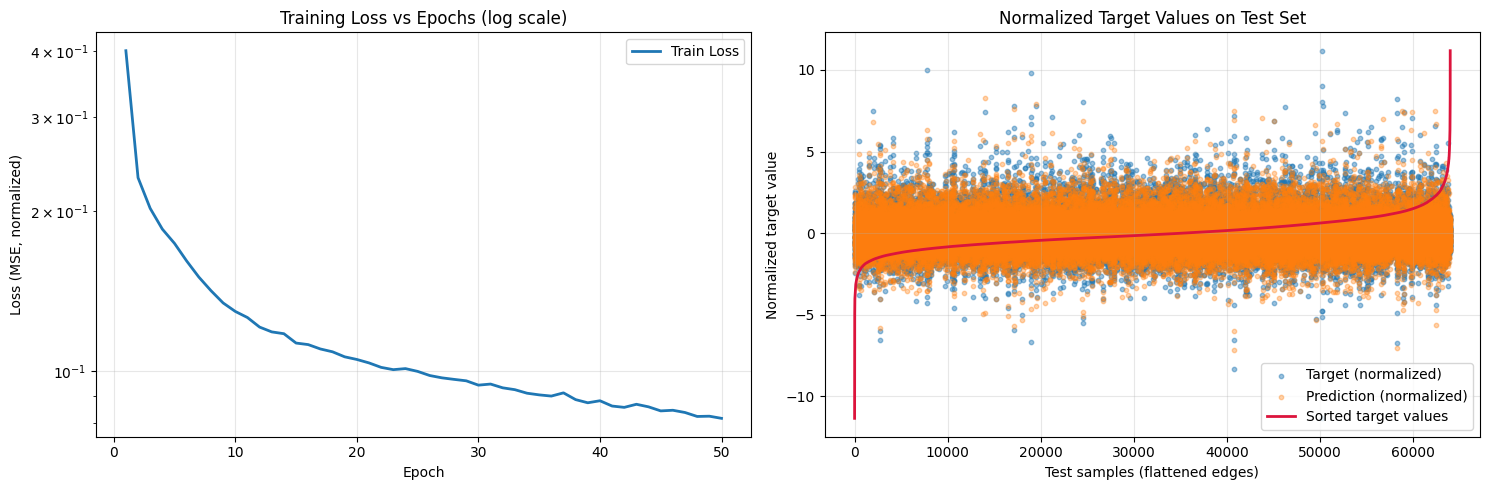

✅ Training visualizations generated.


In [6]:
# TRAINING VISUALS: Loss curve + normalized target distribution on test set
import matplotlib.pyplot as plt
import numpy as np
import torch

# Graceful fallbacks when cell is run in a fresh kernel
epoch_history_local = globals().get("epoch_history", [])
train_loss_history_local = globals().get("train_loss_history", [])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) Loss vs Epochs (log scale for readability)
ax = axes[0]
if len(epoch_history_local) > 0 and len(train_loss_history_local) > 0:
    ax.plot(epoch_history_local, train_loss_history_local, color='tab:blue', linewidth=2, label='Train Loss')
    ax.set_yscale('log')
    ax.set_title('Training Loss vs Epochs (log scale)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, normalized)')
    ax.grid(True, alpha=0.3)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No training history in memory\nRun training cell first', ha='center', va='center')
    ax.set_title('Training Loss vs Epochs')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, normalized)')
    ax.grid(True, alpha=0.3)

# 2) Normalized target values vs test sample index + sorted target line
required = ['model', 'test_loader', 'device']
if all(name in globals() for name in required):
    model.eval()
    all_test_targets_scaled = []
    all_test_preds_scaled = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device, non_blocking=True)
            out = model(batch.x, batch.edge_index)
            all_test_targets_scaled.append(batch.y_edge.detach().cpu().numpy().reshape(-1))
            all_test_preds_scaled.append(out.detach().cpu().numpy().reshape(-1))

    if len(all_test_targets_scaled) > 0:
        target_values = np.concatenate(all_test_targets_scaled)
        pred_values = np.concatenate(all_test_preds_scaled)
        sample_idx = np.arange(target_values.shape[0])

        ax = axes[1]
        ax.scatter(sample_idx, target_values, s=10, alpha=0.45, color='tab:blue', label='Target (normalized)')
        ax.scatter(sample_idx, pred_values, s=10, alpha=0.35, color='tab:orange', label='Prediction (normalized)')
        ax.plot(sample_idx, np.sort(target_values), color='crimson', linewidth=2, label='Sorted target values')
        ax.set_title('Normalized Target Values on Test Set')
        ax.set_xlabel('Test samples (flattened edges)')
        ax.set_ylabel('Normalized target value')
        ax.grid(True, alpha=0.3)
        ax.legend()
    else:
        axes[1].text(0.5, 0.5, 'No test batches available', ha='center', va='center')
        axes[1].set_title('Normalized Target Values on Test Set')
        axes[1].set_xlabel('Test samples (flattened edges)')
        axes[1].set_ylabel('Normalized target value')
        axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Missing model/test data in memory\nRun setup + training cells first', ha='center', va='center')
    axes[1].set_title('Normalized Target Values on Test Set')
    axes[1].set_xlabel('Test samples (flattened edges)')
    axes[1].set_ylabel('Normalized target value')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
training_visuals_fig = fig  # Capture figure reference for evaluation export
plt.show()

print('✅ Training visualizations generated.')

# EXPORT

In [7]:
import joblib
import torch

# Only export if training from scratch (not loading pre-trained)
if USE_PRETRAINED:
    print("\n⏭️  SKIPPING EXPORT (using pre-trained model)")
else:
    print("\n💾 EXPORTING MODEL AND SCALERS...\n")
    
    # Exporteer de scalers die in deze notebook echt gebruikt zijn
    node_scaler_path = config.SM_EXPORT_PATH / f"node_scaler_{prefix_sm}.pkl"
    edge_scaler_path = config.SM_EXPORT_PATH / f"edge_scaler_{prefix_sm}.pkl"
    joblib.dump(node_scaler, node_scaler_path)
    joblib.dump(edge_scaler, edge_scaler_path)

    print(f"Scalers succesvol opgeslagen:")
    print(f"- {node_scaler_path}")
    print(f"- {edge_scaler_path}")

    # Exporteer het getrainde GNN model als state_dict (PyTorch best practice)
    model_path = config.SM_EXPORT_PATH / f"truss_edge_gnn_{prefix_sm}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "node_in_dim": NODE_FEATURE_DIM,
            "hidden_dim": 128,
            "edge_count": EDGE_COUNT,
            "checkpoint_prefix": prefix_sm
        },
        model_path
    )

    print(f"\nModel checkpoint succesvol opgeslagen:")
    print(f"- {model_path}")


💾 EXPORTING MODEL AND SCALERS...

Scalers succesvol opgeslagen:
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\node_scaler_data_3.1_0000.pkl
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\edge_scaler_data_3.1_0000.pkl

Model checkpoint succesvol opgeslagen:
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\truss_edge_gnn_data_3.1_0000.pt


# EVALUATION & VISUALIZATION FOR OVER/UNDERFITTING

In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from model_evaluation import save_evaluation, print_evaluation_metrics

print("Collecting predictions for visualization...")

MODEL EVALUATION METRICS

📊 REGRESSION PERFORMANCE:
   Train R²:  0.9206
   Test R²:   0.8958
   R² Gap:    0.0247  🟢 GOOD

📏 ERROR METRICS (kN):
   Train MAE:  4.1492
   Test MAE:   4.5131
   Train RMSE: 6.6012
   Test RMSE:  7.5203

🎯 INTERPRETATION:
   ✅ GOOD FIT - Model generalizes well!
      • Train and Test R² are close (gap: 0.0247 < 0.05)
      • Predictions are accurate (Test R²: 0.8958)
      • Model ready for deployment



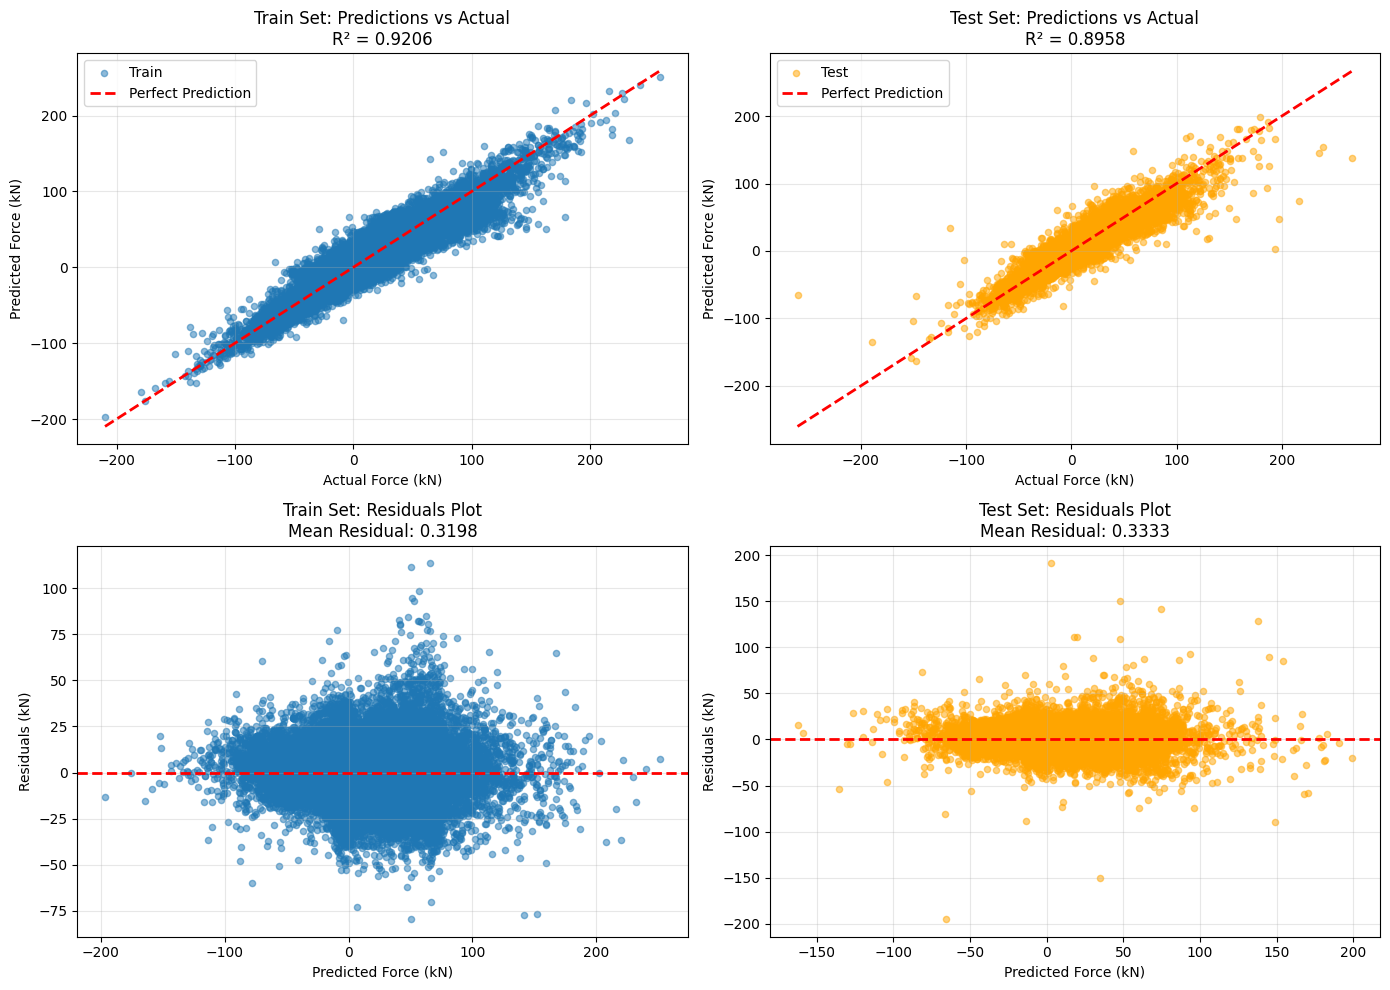

✅ Prediction and residuals plots generated.


In [9]:
# Collect predictions on both train and test sets
model.eval()

train_pred_batches, train_true_batches = [], []
test_pred_batches, test_true_batches = [], []

with torch.no_grad():
	for batch in train_loader:
		batch = batch.to(device, non_blocking=True)
		out = model(batch.x, batch.edge_index)
		train_pred_batches.append(out.detach().cpu())
		train_true_batches.append(batch.y_edge.detach().cpu())

	for batch in test_loader:
		batch = batch.to(device, non_blocking=True)
		out = model(batch.x, batch.edge_index)
		test_pred_batches.append(out.detach().cpu())
		test_true_batches.append(batch.y_edge.detach().cpu())

train_preds_scaled = torch.cat(train_pred_batches, dim=0).numpy()
train_trues_scaled = torch.cat(train_true_batches, dim=0).numpy()
preds_scaled = torch.cat(test_pred_batches, dim=0).numpy()
trues_scaled = torch.cat(test_true_batches, dim=0).numpy()

# Back-transform to original kN scale
train_preds_original = edge_scaler.inverse_transform(train_preds_scaled)
train_trues_original = edge_scaler.inverse_transform(train_trues_scaled)
preds_original = edge_scaler.inverse_transform(preds_scaled)
trues_original = edge_scaler.inverse_transform(trues_scaled)

# Metrics
train_r2 = r2_score(train_trues_original.ravel(), train_preds_original.ravel())
test_r2 = r2_score(trues_original.ravel(), preds_original.ravel())
train_mae = mean_absolute_error(train_trues_original.ravel(), train_preds_original.ravel())
test_mae = mean_absolute_error(trues_original.ravel(), preds_original.ravel())
train_rmse = np.sqrt(mean_squared_error(train_trues_original.ravel(), train_preds_original.ravel()))
test_rmse = np.sqrt(mean_squared_error(trues_original.ravel(), preds_original.ravel()))
r2_gap = abs(train_r2 - test_r2)

metrics = {
    'train_r2': train_r2,
    'test_r2': test_r2,
    'train_mae': train_mae,
    'test_mae': test_mae,
    'train_rmse': train_rmse,
    'test_rmse': test_rmse,
    'r2_gap': r2_gap
}

if (train_r2 - test_r2) > 0.05:
	status = "overfitting"
elif train_r2 < 0.7 and test_r2 < 0.7:
	status = "underfitting"
else:
	status = "good_fit"

# ==========================================
# PRINT PERFORMANCE METRICS & INTERPRETATION
# ==========================================
print_evaluation_metrics(metrics, status)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PREDICTIONS VS ACTUAL (TRAIN SET)
ax = axes[0, 0]
ax.scatter(train_trues_original, train_preds_original, alpha=0.5, s=20, label='Train')
min_val, max_val = train_trues_original.min(), train_trues_original.max()
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Force (kN)')
ax.set_ylabel('Predicted Force (kN)')
ax.set_title(f'Train Set: Predictions vs Actual\nR² = {train_r2:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. PREDICTIONS VS ACTUAL (TEST SET)
ax = axes[0, 1]
ax.scatter(trues_original, preds_original, alpha=0.5, s=20, color='orange', label='Test')
min_val, max_val = trues_original.min(), trues_original.max()
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Force (kN)')
ax.set_ylabel('Predicted Force (kN)')
ax.set_title(f'Test Set: Predictions vs Actual\nR² = {test_r2:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. RESIDUALS (TRAIN SET)
train_residuals = train_trues_original - train_preds_original
ax = axes[1, 0]
ax.scatter(train_preds_original, train_residuals, alpha=0.5, s=20)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Force (kN)')
ax.set_ylabel('Residuals (kN)')
ax.set_title(f'Train Set: Residuals Plot\nMean Residual: {train_residuals.mean():.4f}')
ax.grid(True, alpha=0.3)

# 4. RESIDUALS (TEST SET)
test_residuals = trues_original - preds_original
ax = axes[1, 1]
ax.scatter(preds_original, test_residuals, alpha=0.5, s=20, color='orange')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Force (kN)')
ax.set_ylabel('Residuals (kN)')
ax.set_title(f'Test Set: Residuals Plot\nMean Residual: {test_residuals.mean():.4f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
pred_residuals_fig = fig  # Capture figure reference
plt.show()

print("✅ Prediction and residuals plots generated.")

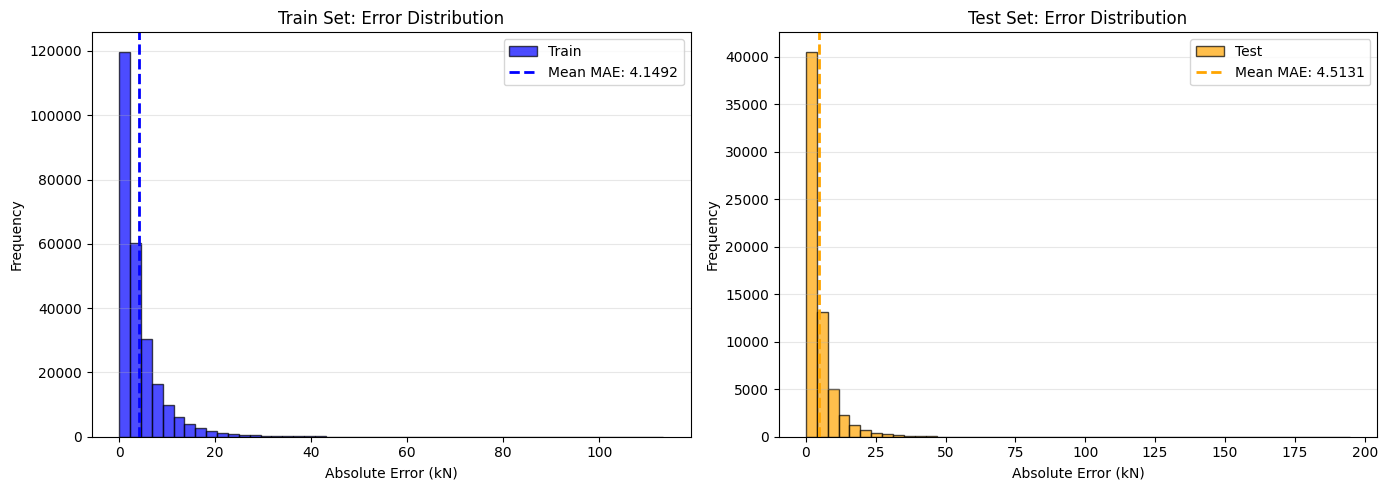

✅ Error distribution plots generated.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ERROR DISTRIBUTION (TRAIN SET)
ax = axes[0]
train_errors = np.abs(train_residuals)
ax.hist(train_errors, bins=50, alpha=0.7, edgecolor='black', color='blue', label='Train')
ax.axvline(train_mae, color='blue', linestyle='--', lw=2, label=f'Mean MAE: {train_mae:.4f}')
ax.set_xlabel('Absolute Error (kN)')
ax.set_ylabel('Frequency')
ax.set_title('Train Set: Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 2. ERROR DISTRIBUTION (TEST SET)
ax = axes[1]
test_errors = np.abs(test_residuals)
ax.hist(test_errors, bins=50, alpha=0.7, edgecolor='black', color='orange', label='Test')
ax.axvline(test_mae, color='orange', linestyle='--', lw=2, label=f'Mean MAE: {test_mae:.4f}')
ax.set_xlabel('Absolute Error (kN)')
ax.set_ylabel('Frequency')
ax.set_title('Test Set: Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
error_dist_fig = fig  # Capture figure reference
plt.show()

print("✅ Error distribution plots generated.")

In [11]:
import importlib
import config
import model_evaluation

# Ensure latest model_evaluation.py changes are loaded in notebook kernel
importlib.reload(model_evaluation)

# SAVE ALL EVALUATION RESULTS TO FILE
saved_files = model_evaluation.save_evaluation(
    model_prefix=model_prefix,
    dataset_name=CSV_FILE,
    metrics=metrics,
    pred_residuals_fig=pred_residuals_fig,
    error_dist_fig=error_dist_fig,
    training_visuals_fig=globals().get("training_visuals_fig"),
    node_count=NODE_COUNT,
    edge_count=EDGE_COUNT,
    export_path=config.SM_DATA_PATH,
    status=status
)


SAVING EVALUATION RESULTS FOR: data_3.1_0000

✅ Metrics saved: metrics_20260331_160558.json
✅ Predictions plot saved: 01_predictions_residuals_20260331_160558.png
✅ Error distribution saved: 02_error_distribution_20260331_160558.png


C:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\src\model_evaluation.py:163: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  training_visuals_fig.savefig(training_plot_path, dpi=150, bbox_inches='tight')


✅ Training diagnostics saved: 03_training_diagnostics_20260331_160558.png
✅ README saved: README.md

📁 All evaluation files saved to:
   C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\02_surrogate_model_data\data_3.1_0000_2026-03-31_160558



## Interpretation Guide

### What to look for:

**OVERFITTING** 🔴 (Train performs much better than Test):
- Train R² >> Test R² (gap > 0.05)
- Train residuals are much smaller than test residuals
- Test error histogram has a heavier right tail
- Predictions vs Actual scatter: train points closer to red line than test points

**UNDERFITTING** 🔴 (Both train and test perform poorly):
- Both R² scores are low (< 0.7)
- Both residuals show large systematic patterns
- Both predictions scatter far from the red diagonal line
- High MAE/RMSE on both train and test

**GOOD FIT** ✅ (Train and Test perform similarly):
- Train and Test R² are close (gap < 0.05)
- Both residuals are centered around 0 with similar spread
- Both scatter plots show points close to diagonal line
- Error distributions are similar and centered

### Remedies:

If **Overfitting**:
- **Gather more training data** ⭐ (most effective long-term solution—model memorizes less with more diverse samples)
- Add dropout layers to the model
- Increase weight decay (L2 regularization)
- Use early stopping on validation loss
- Try reducing model hidden_dim (e.g., 128 → 64)

If **Underfitting**:
- Increase hidden_dim (e.g., 128 → 256)
- Add more GNN layers
- Train for more epochs
- Check if the model has enough capacity for the problem

If **Good Fit**: ✅ Deploy and use in downstream tasks!